# Auto BC Processing

- Loads the hdf file results from the HEC-RAS model hdf output file
- gathers model data and other input data (flow change locations)  
- writes BC conditions (internal and external)

In [1]:
#imports
import os
import pathlib as pl

## Set directories and user defined variables

In [2]:
#set working directory and folder variables
os.chdir('..')
home = pl.Path(os.getcwd())
#user to set variables for the project. tagged as parameter for papermill runs
project = 'wy_fy22'
huc = '1404010608'

In [3]:
home = pl.Path(home)
print('home is at ',home)
assert home.stem == '_code', 'restart kernel and rerun code'
from src.hdf import *

inputs = home/'inputs'
outputs_base = home/'outputs'
#create input and outputs folder if not already dirs
if not os.path.exists(inputs):
    os.makedirs(inputs)
if not os.path.exists(outputs_base):
    os.makedirs(outputs)

home is at  U:\173432208011\studies\1_great_divide_green_watershed\production\engineering_riverine\hydraulics\hydrology_incorporation\_code


In [4]:
#hdf version check
print(h5py.__version__)# Make sure the version is 2.9 or above

3.8.0


In [5]:
#hard variables for project
model_name = f'wy_gdg_{huc}' #folder within inputs folder
junctions = 'shp' #temp
huc_map = {}
start_id = 51
force = True #deletes outputs from any prior runs. Set to False to avoid this

In [6]:
#create output subfolder
if force:
    if os.path.exists(outputs_base/project/model_name):
        shutil.rmtree(outputs_base/project/model_name)
    
if not os.path.exists(outputs_base/project/model_name):
    os.makedirs(outputs_base/project/model_name)
    
outputs = outputs_base/project/model_name
#create plot and notebook output location
#create output subfolder
if not os.path.exists(outputs_base/project/'plots'):
    os.makedirs(outputs_base/project/'plots')
plots = outputs_base/project/'plots'

## Get Relevant RAS Files

In [7]:
plan_path, in_geom_path, in_flow_path = get_current_ras_files(inputs/project/huc[4:8]/huc/f'{model_name}.prj')

## Copy HDF File to output folder for reading

In [8]:
# reset hdf file
geo_out_hdf = shutil.copy(inputs/project/huc[4:8]/huc/f'{model_name}{in_geom_path.suffix}.hdf',outputs/f'{model_name}.g{start_id}.hdf')
geo_out = shutil.copy(inputs/project/huc[4:8]/huc/f'{model_name}{in_geom_path.suffix}',outputs/f'{model_name}.g{start_id}')

## Update Geometry file and HDF Files to include Flow Change locations

In [9]:
#geo hdf
hf_geo = h5py.File(str(geo_out_hdf),'r')

#get domain names
domain_geo = str(list(hf_geo['Geometry']['2D Flow Areas']['Attributes'])[0][0]).strip("'b\'")

#get global projection for all geometric operations. Assume the same between model plans
crs_prj = str(hf_geo.attrs['Projection']).strip("'b\'")

## Load geom hdf data into a geo dataframe

### External BCs

In [10]:
#get downstream domain
geo = gpd.GeoSeries(geometry.Polygon(map(geometry.Point, hf_geo['Geometry']['2D Flow Areas']['Polygon Points'][:]))) 
ds_area = gpd.GeoDataFrame({'name':domain_geo,'geometry':geo}, crs=crs_prj)

In [11]:
#get upstream models
with open(inputs/project/'dictionaries'/'HUC10_outflow_toHUC10.json') as src:
    huc_connect_huc = json.load(src)
with open(inputs/project/'dictionaries'/'HUC10_into_dsJunction.json') as src:
    huc_connect_j = json.load(src)
with open(inputs/project/'dictionaries'/'HUC10_Junctions.json') as src:
    huc_js = json.load(src)
with open(inputs/project/'dictionaries'/'source_if_reservoir.json') as src:
    src_js = json.load(src)
with open(inputs/project/'dictionaries'/'hms_feature_origin_dict.json') as src:
    src_huc_hms = json.load(src)
with open(inputs/project/'dictionaries'/'outofscope_HUC10_to_HUC10.json') as src:
    out_of_scope_huc_inflows = json.load(src)

In [12]:
#get upstream hucs list
us_hucs = []
us_j = []
for key, val in huc_connect_huc.items():
    if val == huc:
        us_hucs.append(key)
        us_j.append(huc_connect_j[key])

In [13]:
print(f'upstream models required are {us_hucs}')

upstream models required are ['1404010603', '1404010604', '1404010605']


In [14]:
#get external boundary conditions from upstream models as inflow bcs
for us_huc in us_hucs:
    us_model_name = f'wy_gdg_{us_huc}' #folder within inputs folder
    assert os.path.exists(inputs/project/us_huc[4:8]/us_huc/f'{us_model_name}.prj'), f'Upstream model {us_model_name} needs to be added to the input project folder at {inputs/project/us_huc[4:8]/us_huc}'
    us_plan_path, us_in_geom_path, us_in_flow_path = get_current_ras_files(inputs/project/us_huc[4:8]/us_huc/f'{us_model_name}.prj')
    
    #get current geometry
    inflow_bc = get_ext_bc_lines(ds_area,f'{us_plan_path}.hdf',bc_line_offset=400)
    
    #add junction name
    inflow_bc['junction'] = us_j[us_hucs.index(us_huc)]
    
    #add slope from input flow file. may want to replace with actual EG from model
    with open (us_in_flow_path,'r') as flow_file:
        content = flow_file.read()
    for bc_name in inflow_bc.name.to_list():
        slope = re.search(f'{bc_name}[\w\W]*Friction Slope=0.\d*',content).group(0).split('=')[-1]
    inflow_bc['slope'] = slope
    
    #concat gdfs if needed
    if us_hucs.index(us_huc) == 0:
        inflow_bcs = inflow_bc
    else:
        inflow_bcs = pd.concat([inflow_bcs,inflow_bc])
if us_hucs:
    inflow_bcs.reset_index(inplace=True,drop=True)
else:
    inflow_bcs = pd.DataFrame(columns=['empty'])

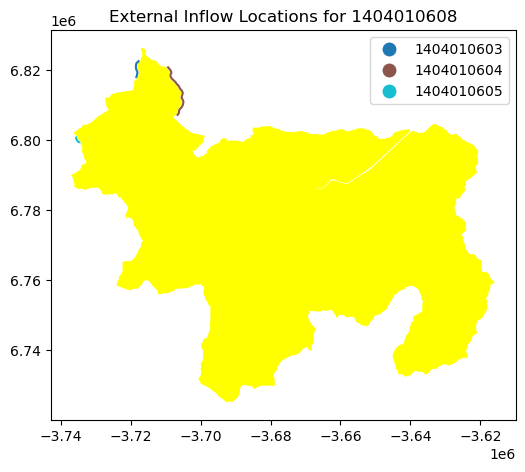

In [15]:
#plot to confirm areas
if not inflow_bcs.empty:
    fig , ax = plt.subplots(figsize=(6,10))
    inflow_bcs.plot(ax = ax, column='huc',legend=True)
    ds_area.plot(ax = ax, color='yellow')
    ax.set_title(f'External Inflow Locations for {huc}')
    plt.savefig(plots/f'{huc}_ext.png')
else:
    print('no upstream model inflows into this huc')

In [16]:
#save to file
if not inflow_bcs.empty:
    inflow_bcs[['name','huc','geometry','junction','slope']].to_file(f'{outputs}/{huc}_ext_forcing_bc_lines.shp')
    #create dictionary for ras dev
    ext_bc_dict = inflow_bcs.to_dict()
    ext_index = inflow_bcs.index.tolist()
else:
    #create empty values
    ext_bc_dict = {}
    ext_index = []
ext_bc_dict['in_flow_path'] = in_flow_path
ext_bc_dict['in_plan_path'] = plan_path

### External BCs for Out of Scope HUCs

In [17]:
#get any out of scope huc inflows
us_oos_hucs = []
us_oos_j = []
for k,v in out_of_scope_huc_inflows.items():
    if v == huc:
        us_oos_hucs.append(k)

for oos_huc in us_oos_hucs:
    us_oos_j.append(huc_connect_j[oos_huc])
if us_oos_hucs:
    print(f'adding additional unscoped upstream models {us_oos_hucs}')
else:
    print('no additional unscoped upstream models to add')

adding additional unscoped upstream models ['1404010606']


In [18]:
#get current geometry
for inflow_huc in us_oos_hucs:
    inflow_bc_oos = get_int_bc_lines(geo_out_hdf,inflow_huc)
    
    #add junction name
    inflow_bc_oos['junction'] = us_oos_j[us_oos_hucs.index(inflow_huc)]
    
    #add slope from input flow file. may want to replace with actual EG from model
    with open (in_flow_path,'r') as flow_file:
        content = flow_file.read()
    for bc_name in inflow_bc_oos.name.to_list():
        slope = re.search(f'{bc_name}[\w\W]*Friction Slope=0.\d*',content).group(0).split('=')[-1]
    inflow_bc_oos['slope'] = slope
    
    #concat gdfs if needed
    if us_oos_hucs.index(inflow_huc) == 0:
        inflow_bcs_oos = inflow_bc_oos
    else:
        inflow_bcs_oos = pd.concat([inflow_bcs_oos,inflow_bc_oos])
if us_oos_hucs:
    inflow_bcs_oos.reset_index(inplace=True,drop=True)
else:
    inflow_bcs_oos = pd.DataFrame(columns=['empty'])

adding out of scope inflow from 1404010606


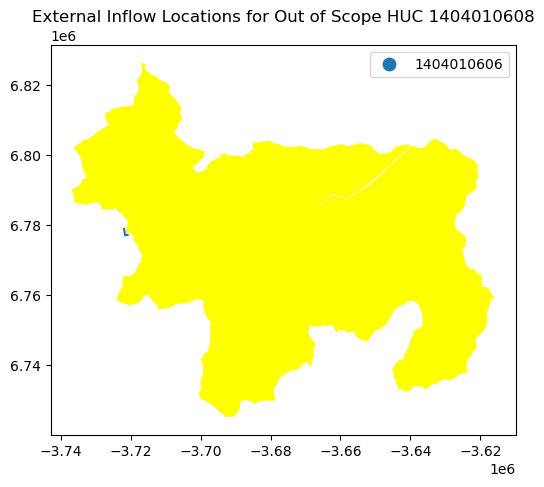

In [19]:
#plot to confirm areas
if not inflow_bcs_oos.empty:
    fig , ax = plt.subplots(figsize=(6,10))
    inflow_bcs_oos.plot(ax = ax, column='huc',legend=True)
    ds_area.plot(ax = ax, color='yellow')
    ax.set_title(f'External Inflow Locations for Out of Scope HUC {huc}')
    plt.savefig(plots/f'{huc}_ext.png')
else:
    print('no inflows into this huc')

In [20]:
#save to file
if not inflow_bcs_oos.empty:
    inflow_bcs_oos[['name','huc','geometry','junction','slope']].to_file(f'{outputs}/{huc}_ext_forcing_bc_lines_oos.shp')
    #create dictionary for ras dev
    ext_bc_dict_oos = inflow_bcs_oos.to_dict()
    ext_index_oos = inflow_bcs_oos.index.tolist()
    inflow_bcs_combined = pd.concat([inflow_bcs, inflow_bcs_oos])
    inflow_bcs_combined.reset_index(inplace=True,drop=True)
    ext_bc_dict_combined = inflow_bcs_combined.to_dict()
    ext_index_combined = inflow_bcs_combined.index.tolist()
else:
    #create empty values
    ext_bc_dict_oos = {}
    ext_index_oos = []
    ext_bc_dict_combined = ext_bc_dict
    ext_index_combined = ext_index
ext_bc_dict_combined['in_flow_path'] = in_flow_path
ext_bc_dict_combined['in_plan_path'] = plan_path

C:\Users\magomez\.conda\envs\regularhome\lib\site-packages\geopandas\array.py:1406: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as USA_Contiguous_Albers_Equal_Area_Conic_USGS_version (the single non-null crs provided).
  warnings.warn(


### Internal BCs - INFLOW

In [21]:
#### Get HMS Data ####
#get events for each recurrence interval from output data
prob_shps = glob.glob(str(inputs/project/huc[4:8]/f'HUC{huc[:8]}'/huc/'*.geojson'))
events_dict = get_sst_storms_by_recurrence(huc,prob_shps,flag=False)

In [22]:
# json.dump(events_dict, open(f'{outputs}/{huc}_events_dict.json', 'w' ) )

In [23]:
#get hms schematic information
schem_folder = inputs/project/huc[4:8]/f'HUC{huc[:8]}_SST_schematic'
if os.path.exists(schem_folder/'hms_plotting'):
    schem_folder = schem_folder/'hms_plotting'
junctions = gpd.read_file(str(schem_folder/f'HUC{huc[:8]}_SST_Junction.shp'))
sinks = gpd.read_file(str(schem_folder/f'HUC{huc[:8]}_SST_Sink.shp'))
if os.path.exists(str(schem_folder/f'HUC{huc[:8]}_SST_Reservoir.shp')):
    reservoirs = gpd.read_file(str(schem_folder/f'HUC{huc[:8]}_SST_Reservoir.shp'))
    hms_points = pd.concat([junctions, sinks,reservoirs]).set_index('index')
else:
    hms_points = pd.concat([junctions, sinks]).set_index('index')
subbasins = gpd.read_file(str(schem_folder/f'HUC{huc[:8]}_SST_Subbasin.shp'))
reaches = gpd.read_file(str(schem_folder/f'HUC{huc[:8]}_SST_Reach.shp'))

In [24]:
##filter to relevant HUC 10
junctions_s_r = hms_points.loc[hms_points.index.isin(huc_js[huc])]

In [25]:
#get external bcs to exclude from internal bc process
if us_hucs:
    #add upstream hucs
    ext_bc_h = list(ext_bc_dict['huc'].values())
    #add out of scope upstream hucs
    if ext_bc_dict_oos:
        for oos_huc in ext_bc_dict_oos['huc'].values():
            ext_bc_h.append(oos_huc)
    #add current huc
    ext_bc_h.append(huc)
    ext_bc_j = []
    #exclude any inflows and outflow points to huc
    for h in ext_bc_h:
        ext_bc_j.append(huc_connect_j[h])
else:
    ext_bc_j = [huc_connect_j[huc]]

In [26]:
#remove any inflow points that are already included as an external boundary condition
int_bcs = junctions_s_r.copy().loc[junctions_s_r.index.isin(ext_bc_j) == False]

In [27]:
####modify to make useful for bc purposes###
#to be consistent with ext code
int_bcs['junction'] = int_bcs.index
#Internal BC EG slope should only impact the normal depth calc used to distribute flow to adjacent cells. 
#Assume uniform value of 0.01 (relatively steep) to force flow to the low point of the cell
int_bcs['slope'] = 0.01

In [28]:
#remove any inflow points that don't have contributing subbasin flows
with open(inputs/project/'dictionaries'/'Junction_Subbasins.json') as src:
    j_connect_sub = json.load(src)

int_bcs['has_contrib_sbs'] = int_bcs['junction'].apply(lambda x: True if j_connect_sub[x] else False)
int_bcs = int_bcs.copy().loc[int_bcs['has_contrib_sbs'] == True]

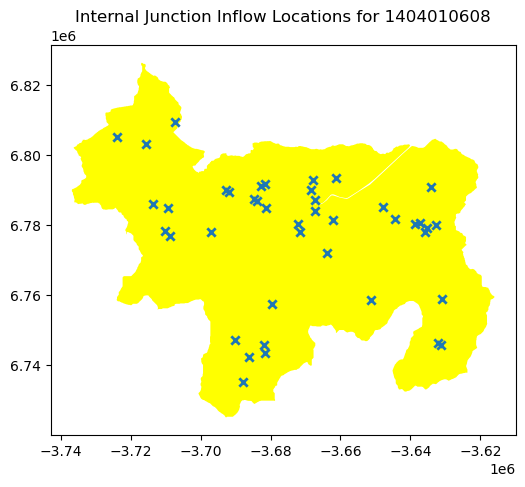

In [29]:
#plot to confirm areas
fig , ax = plt.subplots(figsize=(6,10))
ds_area.plot(ax = ax, color='yellow')
int_bcs.plot(ax=ax,linewidth=2,marker='x')
ax.set_title(f'Internal Junction Inflow Locations for {huc}')
plt.savefig(plots/f'{huc}_int.png')

In [30]:
#turn points into lines
int_bcs['geometry'] = int_bcs['geometry'].apply(lambda mid: LineString([Point(mid.x-1, mid.y-1),Point(mid.x+1, mid.y+1)]))

In [31]:
int_bcs.reset_index(inplace=True)

In [32]:
if not int_bcs.empty:
    int_bcs[['geometry','junction','slope']].to_file(f'{outputs}/{huc}_in_forcing_bc_lines.shp')

In [33]:
int_bc_dict = int_bcs.to_dict()
int_index = int_bcs.index.tolist()
int_bc_dict['in_flow_path'] = in_flow_path
int_bc_dict['in_plan_path'] = plan_path

In [34]:
hf_geo.close()

### Internal BCs - FLOW REDUCTIONS

In [35]:
#get reach junction dictionary
with open(inputs/project/'dictionaries'/'reachfromjunction.json') as src:
    reach_to_us_junction = json.load(src)

In [36]:
##filter to relevant flow reduction reaches\
reaches_col = reaches.columns.to_list()
if 'Channel Lo' in reaches_col:
    cl = 'Channel Lo'
    sb = 'Channel _1'
    rd = 'Channel _2'
else:
    cl = 'Channel _1'
    sb = 'Channel _2'
    rd = 'Channel _3'
flow_r_filter = reaches[cl] == 'Constant'
#channel 2 is initial flow reduction, channel 3 is % reduction of flow hydrograph so adjusted flow hydrograph = (inflow - 5) *.8
reaches_r = reaches.loc[flow_r_filter]
#filter by relevant huc
if huc[:8] == '14040102':
    ds = 'downstream'
else:
    ds = 'Downstream'
reaches_r_s = reaches_r.copy().loc[reaches_r[ds].isin(huc_js[huc]) == True]

In [37]:
if not reaches_r_s.empty:
    reaches_r_s['subtraction'] = reaches_r_s[sb]
    reaches_r_s['reduction'] = reaches_r_s[rd]
else:
    reaches_r_s['subtraction'] = 0
    reaches_r_s['reduction'] = 0
    
reaches_r_s['upstream'] = reaches_r_s['name'].apply(lambda x: reach_to_us_junction[x])

####modify to make useful for bc purposes###
#to be consistent with ext code
reaches_r_s['junction'] = reaches_r_s.name
#Internal BC EG slope should only impact the normal depth calc used to distribute flow to adjacent cells. 
#Assume uniform value of 0.01 (relatively steep) to force flow to the low point of the cell
reaches_r_s['slope'] = 0.01

reaches_r_s.reset_index(inplace=True)
if not reaches_r_s.empty:
    reaches_r_s[['geometry','junction','slope']].to_file(f'{outputs}/{huc}_flow_reduction_forcing_bc_lines.shp')

int_r_bc_dict = reaches_r_s.to_dict()
int_r_index = reaches_r_s.index.tolist()
int_r_bc_dict['in_flow_path'] = in_flow_path
int_r_bc_dict['in_plan_path'] = plan_path

C:\Users\magomez\.conda\envs\regularhome\lib\site-packages\geopandas\plotting.py:693: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(


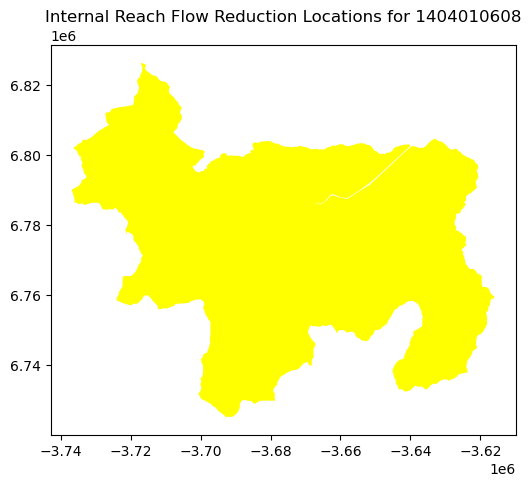

In [38]:
#plot to confirm areas
fig , ax = plt.subplots(figsize=(6,10))
ds_area.plot(ax = ax, color='yellow')
reaches_r_s.plot(ax=ax,linewidth=2,color='red')
ax.set_title(f'Internal Reach Flow Reduction Locations for {huc}')
plt.savefig(plots/f'{huc}_int.png')

In [39]:
hf_geo.close()

### Internal BCs - MAJOR SOURCE ADD INS

In [40]:
#pull out only the inflows that are tagged as reservoirs
src_inflows = {}
for key, value in src_js.items():
    if 'TRUE' in value:
        src_inflows[key] = value['TRUE']
#get hms schematic information for sources
if os.path.exists(str(schem_folder/f'HUC{huc[:8]}_SST_Source.shp')):
    hms_points = gpd.read_file(str(schem_folder/f'HUC{huc[:8]}_SST_Source.shp')).set_index('index')
    ##filter to relevant HUC 10
    hms_points['in_huc'] = hms_points.within(ds_area.iloc[0].geometry)
    junctions_s_r = hms_points.loc[hms_points['in_huc'] == True]
    #filter only new sources of flow from dam operations
    src_bcs = junctions_s_r.copy().loc[junctions_s_r.index.isin(list(src_inflows.keys())) == True]
else:
    src_bcs =pd.DataFrame(columns = ['geometry','junction','slope'], 
                   index = [])

In [41]:
#to be consistent with ext code
src_bcs['junction'] = src_bcs.index
#Internal BC EG slope should only impact the normal depth calc used to distribute flow to adjacent cells. 
#Assume uniform value of 0.01 (relatively steep) to force flow to the low point of the cell
src_bcs['slope'] = 0.01

if not src_bcs.empty:

    #update geometry based on dictionary
    src_bcs['geometry'] = src_bcs.apply(lambda x: Point(src_inflows[x.junction]),axis=1)
else:
    pass

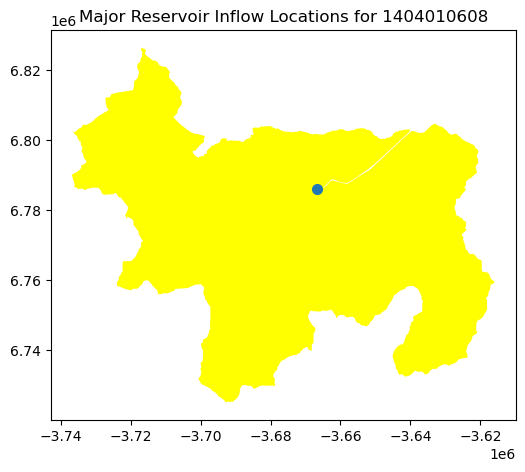

In [42]:
#plot to confirm areas
fig , ax = plt.subplots(figsize=(6,10))
ds_area.plot(ax = ax, color='yellow')
src_bcs.plot(ax=ax,linewidth=2,marker='o')
ax.set_title(f'Major Reservoir Inflow Locations for {huc}')
plt.savefig(plots/f'{huc}_int.png')

In [43]:
#turn points into lines
src_bcs['geometry'] = src_bcs['geometry'].apply(lambda mid: LineString([Point(mid.x-1, mid.y-1),Point(mid.x+1, mid.y+1)]))

In [44]:
src_bcs.reset_index(inplace=True)

In [45]:
src_bcs

,index,Last Modif,Last Mod_1,Canvas X,Canvas Y,From Canva,From Can_1,Downstream,Flow Metho,Flow Gage,End Flow M,Constant F,name,geometry,in_huc,junction,slope
0,Flaming_Gorge_Outflow,11 April 2024,20:25:32,-3664630.2216974976,6784962.163365605,-3664630.2216974976,6784962.163365605,HUC_106_R_507,CONSTANT_FLOW,NaN,NaN,4692,Flaming_Gorge_Outflow,"LINESTRING (-3666635.460 6786159.160, -3666633...",True,Flaming_Gorge_Outflow,0.01


In [46]:
if not src_bcs.empty:
    src_bcs[['geometry','junction','slope']].to_file(f'{outputs}/{huc}_in_forcing_bc_lines_sources.shp')

In [47]:
src_bc_dict = src_bcs.to_dict()
src_index = src_bcs.index.tolist()
src_bc_dict['in_flow_path'] = in_flow_path
src_bc_dict['in_plan_path'] = plan_path

In [48]:
hf_geo.close()

## Update geometry with US external boundary conditions

### Write to geometry text file as new BC Line and breakline

In [49]:
#need to update breakline option to write with the actual perimeter to avoid cell errors.
add_inflow_bcs(in_geom_path,ext_index,ext_bc_dict,domain_geo, geo_out)

In [50]:
#need to update breakline option to write with the actual perimeter to avoid cell errors.
update_oos_bcs(geo_out,ext_index_oos,ext_bc_dict_oos,domain_geo, geo_out)

In [51]:
#need to update to write with the actual perimeter to avoid cell errors.
add_inflow_bcs(geo_out,int_index,int_bc_dict,domain_geo, geo_out)

In [52]:
#need to update to write with the actual perimeter to avoid cell errors.
add_inflow_bcs(geo_out,int_r_index,int_r_bc_dict,domain_geo, geo_out)

In [53]:
#reservoirs
add_inflow_bcs(geo_out,src_index,src_bc_dict,domain_geo, geo_out)

## Create new Unsteady Flow Files and Plan files

### Read input DSS Files

In [54]:
#variables
dss_files = glob.glob(str(inputs/project/huc[4:8]/f'HUC{huc[:8]}'/huc/'dss'/'*.dss'))
dss_files_model = []
if not os.path.exists(outputs/'Hydrology'):
    os.mkdir(outputs/'Hydrology')

### Write Updated RAS Files based on input DSS Files

In [55]:
#only include relevant events
events_req = []
for rec in events_dict[huc].keys():
    events = events_dict[huc][rec]
    for event in events:
        if event not in events_req:
            events_req.append(event)

In [78]:
len(events_req)

17

In [79]:
events_dict

{'1404010608': {'0.002': ['R5-Y274-E0001', 'R8-Y089-E0001'],
  '0.01m': ['R9-Y252-E0003', 'R2-Y474-E0001'],
  '0.01p': ['R6-Y181-E0005', 'R1-Y509-E0002', 'R9-Y461-E0001'],
  '0.01': ['R10-Y055-E0001', 'R2-Y421-E0002', 'R6-Y255-E0001'],
  '0.02': ['R7-Y162-E0003', 'R2-Y421-E0002', 'R8-Y089-E0001'],
  '0.04': ['R3-Y050-E0001', 'R1-Y476-E0001', 'R1-Y468-E0005'],
  '0.1': ['R6-Y482-E0002', 'R1-Y423-E0001', 'R8-Y475-E0004']}}

In [80]:
#find only the relevant DSS files and rename them to include the realization number in the outputs folder
for event in events_req:
    evnt_name = re.search('Y\d+-E\d+',event).group()
    evnt_name_u = evnt_name.replace('-','_')
    criteria = f'\S+(R\d+-)?{evnt_name_u}_output.dss' 
    r = re.compile(criteria)
    dss_matches = list(filter(r.match, dss_files))
    if len(dss_matches) > 1:
        evnt_name_full = re.search('R\d+-Y\d+-E\d+',event).group()
        evnt_name_full_u = evnt_name_full.replace('-','_')
        criteria = f'\S+{evnt_name_full_u}_output.dss' 
        r = re.compile(criteria)
        dss_matches = list(filter(r.match, dss_matches))
    assert len(dss_matches) != 0, "there are no dss files matches"
    assert len(dss_matches) == 1, "there are more than 1 dss files with the same Y and E number that don't have a R number specified"
    out_name = event.replace('-','_')+"_output.dss"
    shutil.copy(dss_matches[0],outputs/'hydrology'/out_name)
    dss_files_model.append(str(outputs/'hydrology'/out_name))

In [81]:
##write dss files to run events using subbasin inflows
dss_matches = write_updated_ext_bc_files(domain_geo,dss_files_model,ext_index_combined,ext_bc_dict_combined,int_index,int_bc_dict,int_r_index,int_r_bc_dict,src_index, src_bc_dict, inputs,outputs,project,huc,start_id,src_huc_hms)

## END